In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time

def get_minute_bars(ticker):
    """
    Fetch minute-by-minute price data for a given stock ticker as far back as yahoo finance allows.

    Args:
    ticker (str): The stock ticker symbol.

    Returns:
    pandas.DataFrame: A DataFrame containing the minute-by-minute price data.
    """

    # Initialize the ticker object
    stock = yf.Ticker(ticker)

    # Set the end date to now and initialize an empty DataFrame for all data
    end_date = datetime.now()
    all_data = pd.DataFrame()

    # Function to fetch data with error handling
    def fetch_data(ticker, start, end, interval='1m'):
        try:
            df = ticker.history(start=start, end=end, interval=interval)
            if df.empty:
                raise ValueError("No data returned")
            return df
        except Exception as e:
            print(f"Error fetching data: {str(e)}")
            return pd.DataFrame()

    # Fetch data in 7-day intervals
    while True:
        start_date = end_date - timedelta(days=7)
        data = fetch_data(stock, start_date, end_date)
        
        if data.empty:
            break
        
        all_data = pd.concat([data, all_data])
        end_date = start_date
        
        print(f"Fetched data from {start_date} to {end_date}")
        
        # Add a 1 second sleep between requests
        time.sleep(0.5)

    if not all_data.empty:
        print(f"\nData retrieved for {ticker}")
        print(f"Total number of minutes of data: {len(all_data)}")
        print(f"Date range: {all_data.index[-1]} to {all_data.index[0]}")
        return all_data
    else:
        print(f"No data available for {ticker}.")
        return None


In [6]:
all_data = get_minute_bars('GC=F')

Fetched data from 2024-10-06 19:47:12.508024 to 2024-10-06 19:47:12.508024
Fetched data from 2024-09-29 19:47:12.508024 to 2024-09-29 19:47:12.508024
Fetched data from 2024-09-22 19:47:12.508024 to 2024-09-22 19:47:12.508024
Fetched data from 2024-09-15 19:47:12.508024 to 2024-09-15 19:47:12.508024


$GC=F: possibly delisted; no price data found  (1m 2024-09-08 19:47:12.508024 -> 2024-09-15 19:47:12.508024)


Error fetching data: No data returned

Data retrieved for GC=F
Total number of minutes of data: 27072
Date range: 2024-10-13 19:37:00-04:00 to 2024-09-15 19:48:00-04:00


In [7]:
all_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-09-15 19:48:00-04:00,2606.899902,2607.300049,2606.800049,2607.300049,0,0.0,0.0
2024-09-15 19:49:00-04:00,2607.399902,2607.699951,2607.300049,2607.699951,55,0.0,0.0
2024-09-15 19:50:00-04:00,2607.600098,2607.899902,2607.500000,2607.500000,69,0.0,0.0
2024-09-15 19:51:00-04:00,2607.399902,2607.399902,2607.100098,2607.100098,34,0.0,0.0
2024-09-15 19:52:00-04:00,2607.100098,2607.500000,2607.100098,2607.399902,25,0.0,0.0
...,...,...,...,...,...,...,...
2024-10-13 19:33:00-04:00,2666.399902,2666.399902,2666.100098,2666.300049,10,0.0,0.0
2024-10-13 19:34:00-04:00,2666.399902,2666.600098,2666.300049,2666.300049,17,0.0,0.0
2024-10-13 19:35:00-04:00,2666.300049,2666.800049,2666.000000,2666.699951,83,0.0,0.0


In [13]:
def mark_asia_open_zones(df, timeframe=4):
    """
    Mark the zones between Asia open and "timeframe" hours later on the dataframe.
    
    Args:
    df (pandas.DataFrame): The dataframe containing minute-by-minute price data.
    timeframe (int): The number of hours after Asia open to mark the zone.
    
    Returns:
    pandas.DataFrame: The dataframe with an additional 'Asia_Open_Zone' column.
    """
    # Ensure the index is timezone-aware in US/Eastern time
    df = df.tz_convert('US/Eastern')
    
    # Determine if each timestamp is in DST
    is_dst = df.index.map(lambda ts: ts.dst() != timedelta(0))

    # Map DST to asia_open_hour
    asia_open_hours = is_dst.map({True: 21, False: 20})

    # Compute asia_open_time and asia_close_time
    dates = df.index.normalize()
    asia_open_times = dates + pd.to_timedelta(asia_open_hours, unit='h')
    asia_close_times = asia_open_times + pd.Timedelta(hours=timeframe)

    # Create 'Asia_Open_Zone' column
    df['Asia_Open_Zone'] = (df.index >= asia_open_times) & (df.index < asia_close_times)
    
    return df

In [14]:
# Apply the function to the all_data dataframe
all_data = mark_asia_open_zones(all_data)

# Display the first few rows of the updated dataframe
print(all_data.head())

# Display some statistics about the Asia Open Zones
asia_open_data = all_data[all_data['Asia_Open_Zone']]
print(f"\nTotal number of minutes in Asia Open Zones: {len(asia_open_data)}")
print(f"Percentage of data in Asia Open Zones: {len(asia_open_data) / len(all_data) * 100:.2f}%")

                                  Open         High          Low        Close  \
Datetime                                                                        
2024-09-15 19:48:00-04:00  2606.899902  2607.300049  2606.800049  2607.300049   
2024-09-15 19:49:00-04:00  2607.399902  2607.699951  2607.300049  2607.699951   
2024-09-15 19:50:00-04:00  2607.600098  2607.899902  2607.500000  2607.500000   
2024-09-15 19:51:00-04:00  2607.399902  2607.399902  2607.100098  2607.100098   
2024-09-15 19:52:00-04:00  2607.100098  2607.500000  2607.100098  2607.399902   

                           Volume  Dividends  Stock Splits  Asia_Open_Zone  
Datetime                                                                    
2024-09-15 19:48:00-04:00       0        0.0           0.0           False  
2024-09-15 19:49:00-04:00      55        0.0           0.0           False  
2024-09-15 19:50:00-04:00      69        0.0           0.0           False  
2024-09-15 19:51:00-04:00      34        0.0   

C:\Users\SamAl\AppData\Local\Temp\ipykernel_19164\1832036307.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Asia_Open_Session_ID'] = (df['Asia_Open_Zone'] & (~df['Asia_Open_Zone'].shift(1).fillna(False))).cumsum()


Total Profit: -276.1264774863798
Win Rate: 12.50%
     Time Direction  Entry_Price    Stop_Loss   Exit_Price  Exit_Time  \
0     850     Short  2605.399902  2606.329907  2606.329907        851   
1    1638     Short  2601.800049  2602.530078  2602.530078       1644   
2    3115     Short  2595.300049  2595.950049  2595.950049       3118   
3    7581      Long  2658.899902  2657.980005  2657.980005       7593   
4    8918      Long  2663.500000  2662.670068  2662.670068       8920   
5    9871     Short  2677.100098  2678.110083  2678.110083       9877   
6   11251      Long  2687.100098  2686.859912  2686.859912      11258   
7   12569     Short  2687.199951  2687.289990  2687.289990      12573   
8   16494     Short  2674.899902  2675.419946  2675.419946      16502   
9   17957     Short  2672.899902  2673.080005  2673.080005      17959   
10  19261      Long  2685.100098  2686.689893  2686.689893      19285   
11  20702     Short  2660.300049  2661.150049  2661.150049      20704   
1

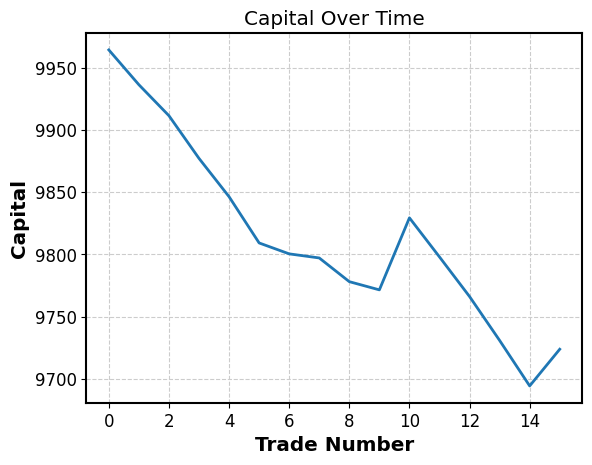

In [29]:
def simulate_trading_strategy(df, breakout_pct=0.2, trailing_stop_pct=0.2, starting_capital=10000, leverage=1):
    """
    Simulate the trading strategy with capital and leverage considerations.
    
    Args:
    df (pandas.DataFrame): The dataframe with minute-by-minute price data and 'Asia_Open_Zone' column.
    breakout_pct (float): Percentage of the range to consider as a breakout.
    trailing_stop_pct (float): Percentage of the range to set as the trailing stop.
    starting_capital (float): The starting capital for the trading simulation.
    leverage (float): The leverage to be used for each trade.
    
    Returns:
    pandas.DataFrame: A dataframe containing the details of each trade executed.
    """
    # Ensure the dataframe is sorted by index
    df = df.sort_index()
    
    # Create a unique ID for each Asia open session
    df['Asia_Open_Session_ID'] = (df['Asia_Open_Zone'] & (~df['Asia_Open_Zone'].shift(1).fillna(False))).cumsum()
    
    # Compute the high and low for each Asia open session
    asia_open_ranges = df[df['Asia_Open_Zone']].groupby('Asia_Open_Session_ID').agg({
        'High': 'max',
        'Low': 'min'
    }).rename(columns={'High': 'Asia_Open_High', 'Low': 'Asia_Open_Low'})
    
    # Forward-fill the session IDs and merge the Asia open ranges back into the dataframe
    df['Asia_Open_Session_ID'] = df['Asia_Open_Session_ID'].ffill()
    df = df.merge(asia_open_ranges, on='Asia_Open_Session_ID', how='left')
    
    # Calculate the range and breakout thresholds
    df['Asia_Open_Range'] = df['Asia_Open_High'] - df['Asia_Open_Low']
    df['Breakout_Threshold'] = breakout_pct * df['Asia_Open_Range']
    
    # Determine if each timestamp is after the Asia open session
    df['After_Asia_Open_Session'] = ~df['Asia_Open_Zone']
    
    # Initialize variables
    all_trades = []
    capital = starting_capital
    capital_over_time = [capital]
    
    # Process each Asia open session individually
    for session_id, group in df.groupby('Asia_Open_Session_ID'):
        if capital <= 0:
            print("Capital exhausted. Stopping simulation.")
            break
        trades = process_trading_strategy(group, breakout_pct, trailing_stop_pct, capital, leverage)
        
        for trade in trades:
            # Update capital based on the profit from the trade
            capital += trade['Profit']
            # Store capital after the trade
            trade['Capital_After_Trade'] = capital
            capital_over_time.append(capital)
        
        all_trades.extend(trades)
    
    # Convert the list of trades into a DataFrame
    trades_df = pd.DataFrame(all_trades)
    return trades_df

def process_trading_strategy(group, breakout_pct, trailing_stop_pct, capital, leverage):
    """
    Process the trading strategy for a single Asia open session with capital and leverage considerations.
    
    Args:
    group (pandas.DataFrame): The dataframe for a single Asia open session.
    breakout_pct (float): Percentage of the range to consider as a breakout.
    trailing_stop_pct (float): Percentage of the range to set as the trailing stop.
    capital (float): The capital available before the trade.
    leverage (float): The leverage to be used for the trade.
    
    Returns:
    list: A list of dictionaries containing trade details.
    """
    # Only process data after the Asia open session
    group = group[group['After_Asia_Open_Session']]
    
    # Initialize variables
    in_breakout = False
    breakout_direction = None  # 'up' or 'down'
    reentered_range = False
    trade_executed = False
    trades = []
    
    # Get the Asia open high, low, and range
    asia_open_high = group['Asia_Open_High'].iloc[0]
    asia_open_low = group['Asia_Open_Low'].iloc[0]
    asia_open_range = asia_open_high - asia_open_low
    breakout_threshold = breakout_pct * asia_open_range
    
    # Define breakout levels
    breakout_up_level = asia_open_high + breakout_threshold
    breakout_down_level = asia_open_low - breakout_threshold
    
    # Trailing stop value
    trailing_stop = trailing_stop_pct * asia_open_range
    
    for idx, row in group.iterrows():
        if not in_breakout:
            # Check for initial breakout
            if row['High'] >= breakout_up_level:
                in_breakout = True
                breakout_direction = 'up'
                breakout_price = row['Close']
            elif row['Low'] <= breakout_down_level:
                in_breakout = True
                breakout_direction = 'down'
                breakout_price = row['Close']
        elif not reentered_range:
            # Check if price re-enters the range
            if (breakout_direction == 'up' and row['Low'] <= asia_open_high):
                reentered_range = True
            elif (breakout_direction == 'down' and row['High'] >= asia_open_low):
                reentered_range = True
        elif not trade_executed:
            # Check for second breakout in the same direction
            if breakout_direction == 'up' and row['High'] >= breakout_up_level:
                # Execute a long trade
                trade_executed = True
                entry_price = row['Close']
                trade_time = idx
                stop_loss = entry_price - trailing_stop
                trades.append({
                    'Time': trade_time,
                    'Direction': 'Long',
                    'Entry_Price': entry_price,
                    'Stop_Loss': stop_loss,
                    'Exit_Price': np.nan,
                    'Exit_Time': np.nan,
                    'Profit': np.nan,
                    'Capital_Before_Trade': capital,
                    'Leverage': leverage
                })
            elif breakout_direction == 'down' and row['Low'] <= breakout_down_level:
                # Execute a short trade
                trade_executed = True
                entry_price = row['Close']
                trade_time = idx
                stop_loss = entry_price + trailing_stop
                trades.append({
                    'Time': trade_time,
                    'Direction': 'Short',
                    'Entry_Price': entry_price,
                    'Stop_Loss': stop_loss,
                    'Exit_Price': np.nan,
                    'Exit_Time': np.nan,
                    'Profit': np.nan,
                    'Capital_Before_Trade': capital,
                    'Leverage': leverage
                })
        elif trade_executed:
            # Manage the trade with a trailing stop
            current_trade = trades[-1]
            if current_trade['Direction'] == 'Long':
                # Update trailing stop
                new_stop_loss = row['Close'] - trailing_stop
                if new_stop_loss > current_trade['Stop_Loss']:
                    current_trade['Stop_Loss'] = new_stop_loss
                # Check if stop loss is hit
                if row['Low'] <= current_trade['Stop_Loss']:
                    exit_price = current_trade['Stop_Loss']
                    exit_time = idx
                    profit = capital * leverage * ((exit_price - current_trade['Entry_Price']) / current_trade['Entry_Price'])
                    current_trade.update({
                        'Exit_Price': exit_price,
                        'Exit_Time': exit_time,
                        'Profit': profit
                    })
                    break  # Exit after trade is closed
            elif current_trade['Direction'] == 'Short':
                # Update trailing stop
                new_stop_loss = row['Close'] + trailing_stop
                if new_stop_loss < current_trade['Stop_Loss']:
                    current_trade['Stop_Loss'] = new_stop_loss
                # Check if stop loss is hit
                if row['High'] >= current_trade['Stop_Loss']:
                    exit_price = current_trade['Stop_Loss']
                    exit_time = idx
                    profit = capital * leverage * ((current_trade['Entry_Price'] - exit_price) / current_trade['Entry_Price'])
                    current_trade.update({
                        'Exit_Price': exit_price,
                        'Exit_Time': exit_time,
                        'Profit': profit
                    })
                    break  # Exit after trade is closed
    return trades

# Example usage:

# Assuming 'df' is your dataframe with price data and 'Asia_Open_Zone' marked
# df = pd.read_csv('your_data.csv', index_col=0, parse_dates=True)
# df = mark_asia_open_zones(df)

# Simulate the trading strategy with starting capital and leverage
trades_df = simulate_trading_strategy(all_data, breakout_pct=0.2, trailing_stop_pct=0.1, starting_capital=10000, leverage=10)

# Calculate total profit
total_profit = trades_df['Profit'].sum()
print(f"Total Profit: {total_profit}")

# Calculate win rate
win_rate = (trades_df['Profit'] > 0).mean() * 100
print(f"Win Rate: {win_rate:.2f}%")

# Display the trades
print(trades_df)

# Plot capital over time
import matplotlib.pyplot as plt

trades_df['Capital_After_Trade'].plot()
plt.title('Capital Over Time')
plt.xlabel('Trade Number')
plt.ylabel('Capital')
plt.show()
